# Data Preprocessing 3 - Encoding Categorical Data

> **MLCourse · Data Science Foundations · 05_data_preprocessing**

Models eat numbers, not words. Encoding converts categories to numbers WITHOUT
inventing fake mathematics. Choosing wrongly silently corrupts your model.

### What you'll learn
- Nominal vs ordinal - the decision that drives everything
- Label encoding and its hidden dangers on nominal data
- Ordinal encoding done right (explicit order)
- One-hot encoding, the dummy-variable trap, and sklearn's production-safe version
- Frequency encoding for high-cardinality columns
- Target encoding: powerful but leakage-prone (concept + warning)
- Grouping rare categories into "Other"
- Datetime feature extraction + cyclical sin/cos encoding
- Assembling everything with ColumnTransformer

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

pd.options.display.width = 120

### 1. Nominal vs ordinal - decide FIRST

| Type | Definition | Examples | Correct encodings |
|---|---|---|---|
| **Ordinal** | meaningful ORDER | S<M<L, low<med<high | ordinal/integer mapping |
| **Nominal** | NO order | cities, colors, blood type | one-hot, frequency, target |

In [2]:
df = pd.DataFrame({
    "city":    ["Berlin", "Oslo", "Tokyo", "Oslo", "Berlin"],   # nominal
    "size":    ["M", "S", "L", "M", "S"],                        # ordinal!
    "plan":    ["basic", "pro", "premium", "basic", "pro"],      # ordinal
})
df

,city,size,plan
0,Berlin,M,basic
1,Oslo,S,pro
2,Tokyo,L,premium
3,Oslo,M,basic
4,Berlin,S,pro


### 2. Label encoding - fast but treacherous

`LabelEncoder` maps categories to 0..k-1. For ORDINAL data that's fine.
For NOMINAL data you just told the model Oslo(2) > Berlin(0) and Tokyo is
"the average of nothing". Linear models will multiply these numbers by weights!

In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["city_label"] = le.fit_transform(df["city"])
print(le.classes_, "-> codes:", df["city_label"].tolist())

# Demonstrate the damage on a tiny linear fit:
rng = np.random.default_rng(42)
y_true = np.array([100., 100., 100., 100., 100.])   # city truly has NO effect...
coef = np.polyfit(df["city_label"], y_true, 1)      # ...but the model still sees slope
print(f"fitted slope on meaningless codes: {coef[0]:+.4f} (should be ~0)")

['Berlin' 'Oslo' 'Tokyo'] -> codes: [0, 1, 2, 1, 0]
fitted slope on meaningless codes: -0.0000 (should be ~0)


> ⚠️ **Common pitfall:** label-encoding a nominal column for a LINEAR model or
neural net injects fake order. Tree models are (mostly) immune; linear models
are not.

### 3. Ordinal encoding done right - YOU define the order


### Explicit mapping dict = full control + self-documenting code.


In [ ]:
size_map   = {"S": 0, "M": 1, "L": 2}
plan_map   = {"basic": 0, "pro": 1, "premium": 2}

df["size_ord"] = df["size"].map(size_map)          # .map leaves NaN for unknowns!
df["plan_ord"] = df["plan"].map(plan_map)
df[["size", "size_ord", "plan", "plan_ord"]]

# The sklearn way - note how WE supply the category order:
ord_enc = OrdinalEncoder(categories=[["S", "M", "L"]])
df["size_sklearn"] = ord_enc.fit_transform(df[["size"]]).astype(int)

# Unknown category at transform-time -> OrdinalEncoder REFUSES by default.
try:
    ord_enc.transform(pd.DataFrame({"size": ["XXL"]}))
except ValueError as err:
    print("ValueError raised:", err)
    print("-> production pipelines use handle_unknown='ignore' or explicit maps")


> 💡 **Pro tip:** prefer `.map(dict)` in notebooks (visible, greppable logic)
and `OrdinalEncoder` inside sklearn Pipelines (fits the train-only workflow).

### 4. One-hot encoding - the nominal workhorse

One column per category, value 0/1. No fake order. Cost: k new columns.

In [5]:
onehot = pd.get_dummies(df["city"], prefix="city")
pd.concat([df["city"], onehot], axis=1)

,city,city_Berlin,city_Oslo,city_Tokyo
0,Berlin,True,False,False
1,Oslo,False,True,False
2,Tokyo,False,False,True
3,Oslo,False,True,False
4,Berlin,True,False,False


### 4.1 The dummy-variable trap

With all k dummies present, `city_berlin + city_oslo + city_tokyo == 1` always -
perfect multicollinearity. Linear algebra hates this. Drop ONE column; the
dropped category becomes the baseline (all-zeros row).

In [6]:
pd.get_dummies(df["city"], drop_first=True)   # k-1 columns, Berlin = baseline

,Oslo,Tokyo
0,False,False
1,True,False
2,False,True
3,True,False
4,False,False


### Trees don't care about collinearity; keep drop_first=False there if you like.


### 4.2 sklearn's OneHotEncoder - built for PRODUCTION


In [8]:
ohe = OneHotEncoder(drop="first", handle_unknown="ignore",
                    sparse_output=False)     # dense array for readability

train_cities = df[["city"]]                  # sklearn wants 2-D input
ohe.fit(train_cities)

print("learned categories:", ohe.categories_)

# New city appears at serving time - get_dummies would CRASH or misalign columns:
new_data = pd.DataFrame({"city": ["Tokyo", "Paris"]})   # Paris never seen!
print("transform survives unknown 'Paris':\n",
      pd.DataFrame(ohe.transform(new_data),
                   columns=ohe.get_feature_names_out()))

learned categories: [array(['Berlin', 'Oslo', 'Tokyo'], dtype=object)]
transform survives unknown 'Paris':
    city_Oslo  city_Tokyo
0        0.0         1.0
1        0.0         0.0


D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


> ⚠️ **Common pitfall:** `get_dummies` at training time + different columns at
serving time = silent model garbage. Use `OneHotEncoder(handle_unknown='ignore')`
fitted ONCE on train, saved with your pipeline.

### 5. High-cardinality columns & frequency encoding

500 cities → 500 dummy columns: sparse, slow, overfit-prone. Alternative:
replace each category by its frequency (or count).

In [9]:
n_rows = 10_000
cities = np.random.choice([f"city_{i:03d}" for i in range(300)],
                          n_rows,
                          p=np.array([0.30] + [0.7/299]*299))   # one dominant city

high_card = pd.DataFrame({"city": cities})

# TRAIN frequencies only (leakage discipline!):
freq = high_card["city"].value_counts(normalize=True)
high_card["city_freq"] = high_card["city"].map(freq).round(4)

high_card.head()

,city,city_freq
0,city_032,0.0023
1,city_278,0.0032
2,city_185,0.0028
3,city_128,0.0024
4,city_000,0.3053


### 5.1 Rare-category grouping → "Other"

Categories below a support threshold carry noise, not signal.

In [10]:
counts = high_card["city"].value_counts()
rare = counts[counts < 50].index                 # seen <50 times
print(f"{len(rare)} of {len(counts)} categories are rare "
      f"({counts[rare].sum()/n_rows:.1%} of rows)")

high_card["city_grouped"] = np.where(high_card["city"].isin(rare),
                                     "Other", high_card["city"])
print(high_card["city_grouped"].value_counts().head(3))

# Now one-hot on city_grouped stays small AND stable.

299 of 300 categories are rare (69.5% of rows)
city_grouped
Other       6947
city_000    3053
Name: count, dtype: int64


### 6. Target encoding - concept + BIG warning

Replace category with mean-of-target for that category. Extremely powerful for
high-cardinality tabular problems - and the #1 source of leaderboard fraud via
LEAKAGE when computed naively on all data.

In [11]:
toy = pd.DataFrame({
    "store": ["A", "B", "A", "C", "B", "C"],
    "sold":  [10, 4, 12, 7, 6, 9],
})

naive = toy.groupby("store")["sold"].mean()       # ⚠️ computed WITH the target rows
toy["store_te_naive"] = toy["store"].map(naive)
print(toy)
print("\n⚠️ In real projects compute it INSIDE cross-validation folds only,")
print("   or use library schemes (category_encoders.TargetEncoder / CV folds).")

  store  sold  store_te_naive
0     A    10            11.0
1     B     4             5.0
2     A    12            11.0
3     C     7             8.0
4     B     6             5.0
5     C     9             8.0

⚠️ In real projects compute it INSIDE cross-validation folds only,
   or use library schemes (category_encoders.TargetEncoder / CV folds).


> ⚠️ **Common pitfall:** naive target encoding memorizes each row's own target
→ spectacular offline scores, disastrous deployment. If you can't explain your
CV scheme, don't target-encode.

### 7. Dates are categorical goldmines

A single timestamp hides many features: year, month, weekday, hour, weekend...

In [12]:
ts = pd.DataFrame({
    "when": pd.to_datetime([
        "2024-01-05 08:15", "2024-06-23 14:40", "2024-12-31 23:05",
        "2024-07-04 11:00", "2024-02-10 19:30",
    ])
})

ts["year"] = ts["when"].dt.year
ts["month"] = ts["when"].dt.month
ts["dow"] = ts["when"].dt.dayofweek               # Mon=0
ts["hour"] = ts["when"].dt.hour
ts["is_weekend"] = ts["dow"] >= 5
ts["month_name"] = ts["when"].dt.month_name()
ts

,when,year,month,dow,hour,is_weekend,month_name
0,2024-01-05 08:15:00,2024,1,4,8,False,January
1,2024-06-23 14:40:00,2024,6,6,14,True,June
2,2024-12-31 23:05:00,2024,12,1,23,False,December
3,2024-07-04 11:00:00,2024,7,3,11,False,July
4,2024-02-10 19:30:00,2024,2,5,19,True,February


### 7.1 Cyclical encoding - because hour 23 and hour 0 are NEIGHBORS

Plain integers tell a model 23 > 0 and distance(23, 0) = 23. Sin/cos put them
on a circle where they touch.

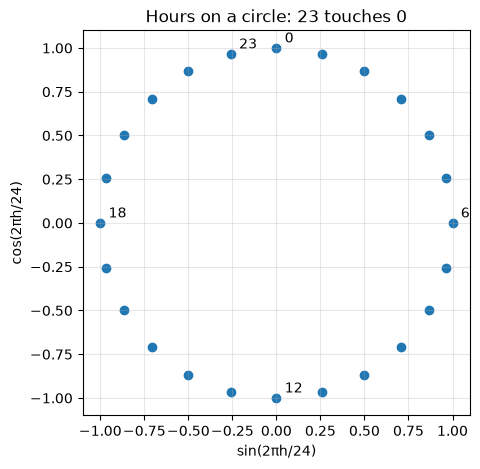

,hour,hr_sin,hr_cos
0,8,0.866,-0.500
1,14,-0.500,-0.866
2,23,-0.259,0.966
3,11,0.259,-0.966
4,19,-0.966,0.259


In [13]:
hours = np.arange(24)
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(np.sin(2*np.pi*hours/24), np.cos(2*np.pi*hours/24))
for h in [0, 6, 12, 18, 23]:
    x_, y_ = np.sin(2*np.pi*h/24), np.cos(2*np.pi*h/24)
    ax.annotate(h, (x_, y_), xytext=(6, 4), textcoords="offset points")
ax.set_title("Hours on a circle: 23 touches 0")
ax.set_xlabel("sin(2πh/24)"); ax.set_ylabel("cos(2πh/24)")
ax.grid(alpha=.3); plt.show()

ts["hr_sin"] = np.sin(2*np.pi*ts["hour"]/24).round(3)
ts["hr_cos"] = np.cos(2*np.pi*ts["hour"]/24).round(3)
ts[["hour", "hr_sin", "hr_cos"]]

# Same trick for month/day-of-week whenever cycles matter (demand, traffic...).

### 8. Assembling everything - ColumnTransformer

Different columns need different treatments. `ColumnTransformer` routes each
column group to its transformer and glues outputs side-by-side.

In [14]:
raw = pd.DataFrame({
    "age": [25, 32, np.nan, 47, 22],
    "fare": [70.5, 8.0, 15.9, np.nan, 7.2],
    "sex": ["male", "female", "female", "male", "female"],
    "embarked": ["S", "C", "S", np.nan, "Q"],
})

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

numeric_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="median")),   # fill NaNs first
    ("scale", StandardScaler()),                    # then scale
])

cat_pipe = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),   # mode-fill embarked
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, ["age", "fare"]),
    ("cat", cat_pipe, ["sex", "embarked"]),
], remainder="drop")

X_ready = preprocessor.fit_transform(raw)           # numpy array, model-ready!
print(X_ready.round(2))

feature_names = preprocessor.get_feature_names_out()
print("\ncolumns:", list(feature_names))

# Everything reproducible in ONE object you can save/pickle with your model.

[[-0.68  1.98  0.    1.    0.    0.    1.  ]
 [ 0.13 -0.61  1.    0.    1.    0.    0.  ]
 [-0.28 -0.28  1.    0.    0.    0.    1.  ]
 [ 1.85 -0.45  0.    1.    0.    0.    1.  ]
 [-1.02 -0.64  1.    0.    0.    1.    0.  ]]

columns: ['num__age', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S']


### Decision flowchart (summary table)

| Situation | Reach for |
### |---|---|
### | ordered grades/sizes/plans | explicit `.map` dict or `OrdinalEncoder(categories=...)` |
### | nominal, few categories, linear model | one-hot (`drop_first=True`) |
### | nominal, few categories, trees | one-hot (drop_first optional) |
### | nominal, hundreds of levels | rare-grouping → frequency/target encoding |
### | unseen categories expected in prod | `OneHotEncoder(handle_unknown="ignore")` |
### | timestamps | extract features + cyclical sin/cos |

### Summary & key takeaways

- **Nominal vs ordinal decides everything** - never label-encode nominals for
  linear models.
- One-hot kills fake order; watch the **dummy trap** (k-1 for linear models).
- Production ≠ notebook: `OneHotEncoder(handle_unknown="ignore")` fitted once
  beats fragile `get_dummies`.
- High cardinality: group rares → frequency encode (train frequencies ONLY).
- Target encoding is leakage lightning - needs CV-safe computation.
- Dates explode into year/month/dow/hour/weekend features; cyclic ones deserve
  sin/cos circles.
- `ColumnTransformer` + `Pipeline` = one reproducible object from raw frame to
  model-ready matrix.